# Download NASA FIRMS Active Fire Detections

This notebook demonstrates how to retrieve satellite-detected active fire hotspots from NASA's Fire Information for Resource Management System (FIRMS) API.

**What you'll get:**
- Real-time and near-real-time fire detections from VIIRS, MODIS, and LANDSAT satellites
- High-confidence fire locations with timestamps
- Brightness temperature and fire radiative power data
- CSV export and interactive map visualization

**Use cases:**
- Early fire detection before perimeters are mapped
- Validation of fire spread predictions
- Spotting and satellite fire detection
- Temporal analysis of fire activity

**Data sources:**
- **VIIRS:** 375m resolution, ~12 hour latency, 01/20/2012-Present (S-NPP) and 04/01/2018-Present (NOAA-20)
- **MODIS:** 1km resolution, ~3 hour latency, 11/2000-Present (Terra) and 07/2002-Present (Aqua)
-  **LANDSAT (US/Canada only):** 30m resolution, ~30 minute latency, 06/20/2022-Present

**API Documentation:** https://firms.modaps.eosdis.nasa.gov/api/

---

## Step 1: Setup

Import required libraries and set API configuration.

In [27]:
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
import json
import contextily as ctx

print("✓ Libraries loaded")

✓ Libraries loaded


## Step 2: Configure Query Parameters

**Get your NASA FIRMS API key (MAP_KEY):**
1. Visit: https://firms.modaps.eosdis.nasa.gov/api/area/
2. Click "Get MAP_KEY" and enter your email
3. Copy the key from the confirmation email

**Query options:**
- **Area of interest:** Define bounding box around your fire
- **Time range:** Last 1-5 days (or specific date range)
- **Satellite source:** VIIRS, MODIS, or LANDSAT
- **Day/Night:** Filter by acquisition time

In [28]:
# =============================================================================
# USER INPUTS - Customize these for your fire
# =============================================================================

# NASA FIRMS API Key (required)
MAP_KEY = "b38da98e9b7e9389fd05a00c32f99783"  # Replace with your own key from https://firms.modaps.eosdis.nasa.gov/api/area/

# Fire location and area of interest
FIRE_NAME = "BORDER 2"
CENTER_LAT = 32.601   # Center latitude
CENTER_LON = -116.841  # Center longitude
RADIUS_KM = 10         # Radius around center point (km)

# Time range (UTC)
START_DATE = "2025-01-23"  # YYYY-MM-DD
END_DATE = "2025-01-30"    # YYYY-MM-DD

# Satellite source
# Options: "VIIRS_SNPP_NRT", "VIIRS_NOAA20_NRT", "MODIS_NRT" (Aqua+Terra combined)
SOURCE = "LANDSAT_NRT"  # For US/Canada

# Output directory
OUTPUT_DIR = Path(f"firms_{FIRE_NAME.lower().replace(' ', '_')}")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Configuration:")
print(f"  Fire: {FIRE_NAME}")
print(f"  Location: ({CENTER_LAT}, {CENTER_LON})")
print(f"  Radius: {RADIUS_KM} km")
print(f"  Dates: {START_DATE} to {END_DATE}")
print(f"  Source: {SOURCE}")
print(f"  Output: {OUTPUT_DIR}/")

Configuration:
  Fire: BORDER 2
  Location: (32.601, -116.841)
  Radius: 10 km
  Dates: 2025-01-23 to 2025-01-30
  Source: LANDSAT_NRT
  Output: firms_border_2/


## Step 3: Construct Bounding Box

Create a bounding box around the fire location. FIRMS API uses format: `min_lon,min_lat,max_lon,max_lat`

In [29]:
# Create point and buffer to get bounding box
point_gdf = gpd.GeoDataFrame(
    geometry=[Point(CENTER_LON, CENTER_LAT)],
    crs="EPSG:4326"
)

# Convert to UTM for accurate distance buffer
utm_crs = point_gdf.estimate_utm_crs()
point_utm = point_gdf.to_crs(utm_crs)

# Buffer by radius (convert km to meters)
buffer_utm = point_utm.buffer(RADIUS_KM * 1000)

# Convert back to WGS84 and get bounds
buffer_wgs84 = buffer_utm.to_crs("EPSG:4326")
minx, miny, maxx, maxy = buffer_wgs84.total_bounds

# FIRMS API format: min_lon,min_lat,max_lon,max_lat
bbox_str = f"{minx},{miny},{maxx},{maxy}"

print(f"\nBounding box:")
print(f"  Min Lon: {minx:.4f}°")
print(f"  Min Lat: {miny:.4f}°")
print(f"  Max Lon: {maxx:.4f}°")
print(f"  Max Lat: {maxy:.4f}°")
print(f"\n  API string: {bbox_str}")


Bounding box:
  Min Lon: -116.9476°
  Min Lat: 32.5108°
  Max Lon: -116.7344°
  Max Lat: 32.6912°

  API string: -116.94757100758696,32.51079016082401,-116.73442970404626,32.691208541268885


## Step 4: Query FIRMS API

Retrieve active fire detections from NASA FIRMS.

In [30]:
# Construct API URL
# Format: https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{source}/{bbox}/{day_range}/{date}

# Calculate day range (FIRMS API uses number of days back from end date)
start_dt = datetime.strptime(START_DATE, "%Y-%m-%d")
end_dt = datetime.strptime(END_DATE, "%Y-%m-%d")
day_range = 5  # Maximum day range for FIRMS API

# FIRMS API endpoint
url = f"https://firms.modaps.eosdis.nasa.gov/usfs/api/area/csv/{MAP_KEY}/{SOURCE}/{bbox_str}/{day_range}/{START_DATE}"

print(f"Querying FIRMS API...")
print(f"  URL: {url}")

try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    # Parse CSV response
    from io import StringIO
    csv_data = StringIO(response.text)
    
    # Read into DataFrame
    hotspots_df = pd.read_csv(csv_data)
    
    print(f"\n✓ Retrieved {len(hotspots_df)} fire detections")
    
except requests.exceptions.HTTPError as e:
    if response.status_code == 404:
        print("\n⚠ No fire detections found in this area and time range")
        hotspots_df = pd.DataFrame()
    else:
        print(f"\n❌ API Error: {e}")
        print("Check your MAP_KEY and try again")
        raise

# Display sample if data exists
if not hotspots_df.empty:
    print(f"\nSample detections:")
    print(hotspots_df.head())

Querying FIRMS API...
  URL: https://firms.modaps.eosdis.nasa.gov/usfs/api/area/csv/b38da98e9b7e9389fd05a00c32f99783/LANDSAT_NRT/-116.94757100758696,32.51079016082401,-116.73442970404626,32.691208541268885/5/2025-01-23

✓ Retrieved 4 fire detections

Sample detections:
    latitude   longitude  path  row  scan  track    acq_date  acq_time  \
0  32.526742 -116.778994    40   37  5129   6289  2025-01-23      1822   
1  32.527012 -116.778993    40   37  5129   6288  2025-01-23      1822   
2  32.527012 -116.778674    40   37  5130   6288  2025-01-23      1822   
3  32.527283 -116.778993    40   37  5129   6287  2025-01-23      1822   

  satellite confidence daynight  
0        L9          H        D  
1        L9          H        D  
2        L9          H        D  
3        L9          H        D  


## Step 5: Process and Filter Data

Filter for high-confidence detections and parse timestamps.

In [31]:
if not hotspots_df.empty:
    # Parse acquisition time (combine acq_date and acq_time)
    hotspots_df['datetime'] = pd.to_datetime(
        hotspots_df['acq_date'] + ' ' + hotspots_df['acq_time'].astype(str).str.zfill(4),
        format='%Y-%m-%d %H%M'
    )
    
    # Filter for high confidence detections only
    # Confidence levels: H (high), M (medium), L (low)
    high_confidence = hotspots_df[hotspots_df['confidence'].isin(['H', 'M'])].copy()
    
    print(f"\nData filtering:")
    print(f"  Total detections: {len(hotspots_df)}")
    print(f"  High confidence: {len(high_confidence)}")
    print(f"  Low confidence (filtered out): {len(hotspots_df) - len(high_confidence)}")
    
    # Use high confidence detections for analysis
    hotspots_df = high_confidence
    
    # Sort by time
    hotspots_df = hotspots_df.sort_values('datetime').reset_index(drop=True)
    
    # Display temporal coverage
    if len(hotspots_df) > 0:
        print(f"\nTemporal coverage:")
        print(f"  First detection: {hotspots_df['datetime'].min()}")
        print(f"  Last detection: {hotspots_df['datetime'].max()}")
        print(f"  Duration: {(hotspots_df['datetime'].max() - hotspots_df['datetime'].min()).total_seconds() / 3600:.1f} hours")
        
        # Count by day/night
        day_count = (hotspots_df['daynight'] == 'D').sum()
        night_count = (hotspots_df['daynight'] == 'N').sum()
        print(f"\n  Day detections: {day_count}")
        print(f"  Night detections: {night_count}")
        
        # Count by satellite
        sat_counts = hotspots_df['satellite'].value_counts()
        print(f"\n  Detections by satellite:")
        for sat, count in sat_counts.items():
            print(f"    {sat}: {count}")
else:
    print("No data to process")


Data filtering:
  Total detections: 4
  High confidence: 4
  Low confidence (filtered out): 0

Temporal coverage:
  First detection: 2025-01-23 18:22:00
  Last detection: 2025-01-23 18:22:00
  Duration: 0.0 hours

  Day detections: 4
  Night detections: 0

  Detections by satellite:
    L9: 4


## Step 6: Convert to GeoDataFrame

Create spatial geometries for mapping and analysis.

In [32]:
if not hotspots_df.empty:
    # Create point geometries
    geometry = [Point(lon, lat) for lon, lat in zip(hotspots_df['longitude'], hotspots_df['latitude'])]
    
    hotspots_gdf = gpd.GeoDataFrame(
        hotspots_df,
        geometry=geometry,
        crs="EPSG:4326"
    )
    
    # Convert to FARSITE CRS (NAD83 Albers)
    hotspots_gdf = hotspots_gdf.to_crs("EPSG:5070")
    
    print(f"\n✓ Created GeoDataFrame with {len(hotspots_gdf)} hotspots")
    print(f"  CRS: {hotspots_gdf.crs}")
    
    # Display key columns
    print(f"\nKey data columns:")
    print(f"  - latitude, longitude: Location (WGS84)")
    print(f"  - satellite: Satellite sensor (e.g., L9=Landsat-9)")
    print(f"  - confidence: Detection confidence (H=high, M=medium, L=low)")
    print(f"  - daynight: Day (D) or Night (N) acquisition")
    print(f"  - datetime: Acquisition timestamp (UTC)")
    print(f"\nNote: Landsat data doesn't include FRP or brightness temperature.")
    print(f"      For those metrics, use VIIRS or MODIS sources.")
else:
    hotspots_gdf = gpd.GeoDataFrame()
    print("No data to convert")


✓ Created GeoDataFrame with 4 hotspots
  CRS: EPSG:5070

Key data columns:
  - latitude, longitude: Location (WGS84)
  - satellite: Satellite sensor (e.g., L9=Landsat-9)
  - confidence: Detection confidence (H=high, M=medium, L=low)
  - daynight: Day (D) or Night (N) acquisition
  - datetime: Acquisition timestamp (UTC)

Note: Landsat data doesn't include FRP or brightness temperature.
      For those metrics, use VIIRS or MODIS sources.


## Step 7: Calculate Statistics

Analyze fire radiative power and detection patterns.

In [33]:
if not hotspots_gdf.empty:
    # Basic statistics
    stats = {
        'total_detections': len(hotspots_gdf),
        'unique_dates': hotspots_gdf['acq_date'].nunique(),
        'spatial_extent_km2': (hotspots_gdf.unary_union.convex_hull.area / 1e6),
    }
    
    # Add FRP/brightness stats only if columns exist (not in Landsat data)
    if 'frp' in hotspots_gdf.columns:
        stats['frp_mean'] = hotspots_gdf['frp'].mean()
        stats['frp_max'] = hotspots_gdf['frp'].max()
        stats['frp_total'] = hotspots_gdf['frp'].sum()
    
    if 'bright_ti4' in hotspots_gdf.columns:
        stats['brightness_mean'] = hotspots_gdf['bright_ti4'].mean()
        stats['brightness_max'] = hotspots_gdf['bright_ti4'].max()
    
    print(f"\n{'='*60}")
    print(f"Fire Detection Statistics")
    print(f"{'='*60}")
    print(f"Total detections:        {stats['total_detections']}")
    print(f"Unique dates:            {stats['unique_dates']}")
    
    if 'frp_mean' in stats:
        print(f"Fire Radiative Power:")
        print(f"  Mean FRP:              {stats['frp_mean']:.1f} MW")
        print(f"  Max FRP:               {stats['frp_max']:.1f} MW")
        print(f"  Total FRP:             {stats['frp_total']:.1f} MW")
    
    if 'brightness_mean' in stats:
        print(f"Brightness Temperature:")
        print(f"  Mean:                  {stats['brightness_mean']:.1f} K")
        print(f"  Max:                   {stats['brightness_max']:.1f} K")
    
    print(f"Spatial extent:          {stats['spatial_extent_km2']:.2f} km²")
    print(f"{'='*60}")
    
    if 'frp' not in hotspots_gdf.columns:
        print(f"\nNote: FRP and brightness data not available for Landsat.")
        print(f"      Use VIIRS or MODIS sources for fire intensity metrics.")
    
    # Save statistics
    stats_file = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_firms_stats.json"
    with open(stats_file, 'w') as f:
        json.dump(stats, f, indent=2, default=str)
    print(f"\n✓ Statistics saved to {stats_file}")
else:
    print("No data for statistics")


Fire Detection Statistics
Total detections:        4
Unique dates:            1
Spatial extent:          0.00 km²

Note: FRP and brightness data not available for Landsat.
      Use VIIRS or MODIS sources for fire intensity metrics.

✓ Statistics saved to firms_border_2/border_2_firms_stats.json


/tmp/ipykernel_1531/223594965.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  'spatial_extent_km2': (hotspots_gdf.unary_union.convex_hull.area / 1e6),


## Step 8: Export Data

Save hotspots as CSV and GeoJSON for use in other applications.

In [34]:
if not hotspots_gdf.empty:
    # Save as CSV
    csv_file = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_firms_hotspots.csv"
    hotspots_df.to_csv(csv_file, index=False)
    print(f"✓ CSV saved to {csv_file}")
    
    # Save as GeoJSON (convert back to WGS84 for compatibility)
    geojson_file = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_firms_hotspots.geojson"
    hotspots_gdf.to_crs("EPSG:4326").to_file(geojson_file, driver="GeoJSON")
    print(f"✓ GeoJSON saved to {geojson_file}")
    
    print(f"\nFiles ready for:")
    print(f"  - Analysis in pandas/geopandas")
    print(f"  - Visualization in QGIS/ArcGIS")
    print(f"  - Web mapping applications")
else:
    print("No data to export")

✓ CSV saved to firms_border_2/border_2_firms_hotspots.csv
✓ GeoJSON saved to firms_border_2/border_2_firms_hotspots.geojson

Files ready for:
  - Analysis in pandas/geopandas
  - Visualization in QGIS/ArcGIS
  - Web mapping applications


## Step 9: Visualize Detections

Create maps showing fire hotspots colored by acquisition time and fire intensity.

✓ Basemap added


/tmp/ipykernel_1531/1865074075.py:61: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hull = hotspots_gdf.unary_union.convex_hull



✓ Spatial map saved to firms_border_2/border_2_firms_spatial_map.png


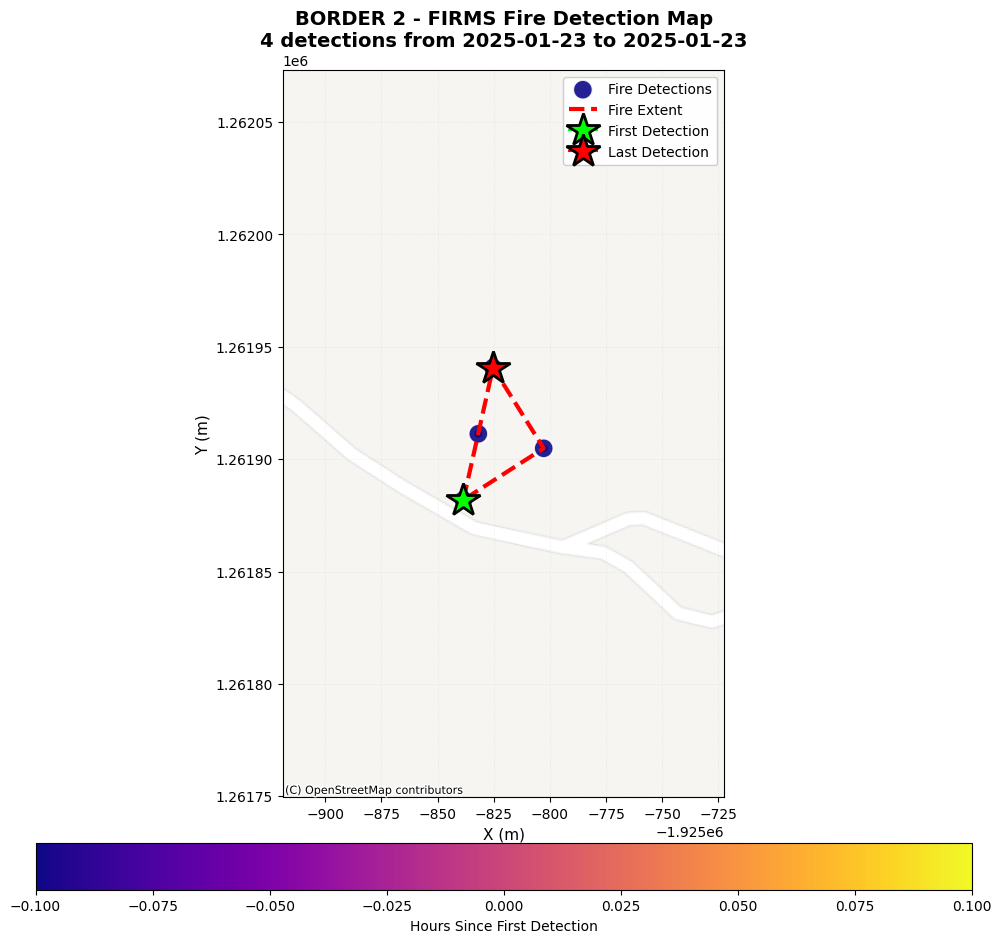


Spatial Detection Summary
Total detections:        4
Spatial extent:          0.00 km²
Time span:               0.0 hours
Fire centroid:           32.5270°N, -116.7789°W

Detections by satellite:
  L9: 4

Detections by time:
  Day:   4 (100.0%)
  Night: 0 (0.0%)


/tmp/ipykernel_1531/1865074075.py:109: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  print(f"Spatial extent:          {hotspots_gdf.unary_union.convex_hull.area / 1e6:.2f} km²")
/tmp/ipykernel_1531/1865074075.py:113: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = hotspots_gdf.unary_union.centroid


In [43]:
if not hotspots_gdf.empty:
    # Create spatial map showing all detections
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Convert datetime to numeric for color gradient
    hotspots_gdf['time_numeric'] = (hotspots_gdf['datetime'] - hotspots_gdf['datetime'].min()).dt.total_seconds() / 3600
    
    # Plot hotspots FIRST to set the extent
    hotspots_gdf.plot(
        ax=ax,
        column='time_numeric',
        cmap='plasma',
        markersize=50,
        alpha=0.9,
        edgecolor='white',
        linewidth=1.5,
        legend=True,
        legend_kwds={
            'label': 'Hours Since First Detection',
            'shrink': 0.8,
            'orientation': 'horizontal',
            'pad': 0.05
        }
    )
    
    # Zoom out by expanding the view
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_margin = (xlim[1] - xlim[0]) * 2.0  # 200% margin = 3x wider view
    y_margin = (ylim[1] - ylim[0]) * 2.0  # 200% margin = 3x taller view
    ax.set_xlim(xlim[0] - x_margin, xlim[1] + x_margin)
    ax.set_ylim(ylim[0] - y_margin, ylim[1] + y_margin)
    
    # Add basemap in the background
    try:
        ctx.add_basemap(
            ax, 
            crs=hotspots_gdf.crs.to_string(), 
            source=ctx.providers.OpenStreetMap.Mapnik,
            zoom='auto',  # Use 'auto' to let it calculate based on the expanded extent
            alpha=0.6,
            zorder=0
        )
        print("✓ Basemap added")
    except Exception as e:
        print(f"Note: Could not add basemap: {e}")
    
    # Re-plot points on top to ensure they're visible
    hotspots_gdf.plot(
        ax=ax,
        column='time_numeric',
        cmap='plasma',
        markersize=200,
        alpha=0.9,
        edgecolor='white',
        linewidth=1.5,
        label='Fire Detections'
    )
    
    # Add convex hull
    hull = hotspots_gdf.unary_union.convex_hull
    gpd.GeoSeries([hull], crs=hotspots_gdf.crs).boundary.plot(
        ax=ax,
        color='red',
        linewidth=3,
        linestyle='--',
        label='Fire Extent'
    )
    
    # Add markers for first and last detection
    first_det = hotspots_gdf.iloc[0]
    last_det = hotspots_gdf.iloc[-1]
    
    ax.plot(first_det.geometry.x, first_det.geometry.y, 
            marker='*', markersize=25, color='lime', 
            markeredgecolor='black', markeredgewidth=2,
            label='First Detection')
    
    ax.plot(last_det.geometry.x, last_det.geometry.y, 
            marker='*', markersize=25, color='red', 
            markeredgecolor='black', markeredgewidth=2,
            label='Last Detection')
    
    # Formatting
    ax.set_title(f'{FIRE_NAME} - FIRMS Fire Detection Map\n'
                 f'{len(hotspots_gdf)} detections from {hotspots_gdf["datetime"].min().strftime("%Y-%m-%d")} '
                 f'to {hotspots_gdf["datetime"].max().strftime("%Y-%m-%d")}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('X (m)', fontsize=11)
    ax.set_ylabel('Y (m)', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=100)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    
    # Save figure
    fig_file = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_firms_spatial_map.png"
    plt.savefig(fig_file, dpi=200, bbox_inches='tight')
    print(f"\n✓ Spatial map saved to {fig_file}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"Spatial Detection Summary")
    print(f"{'='*80}")
    print(f"Total detections:        {len(hotspots_gdf)}")
    print(f"Spatial extent:          {hotspots_gdf.unary_union.convex_hull.area / 1e6:.2f} km²")
    print(f"Time span:               {(hotspots_gdf['datetime'].max() - hotspots_gdf['datetime'].min()).total_seconds() / 3600:.1f} hours")
    
    # Calculate centroid
    centroid = hotspots_gdf.unary_union.centroid
    centroid_wgs84 = gpd.GeoSeries([centroid], crs="EPSG:5070").to_crs("EPSG:4326").iloc[0]
    print(f"Fire centroid:           {centroid_wgs84.y:.4f}°N, {centroid_wgs84.x:.4f}°W")
    
    # Count by satellite
    print(f"\nDetections by satellite:")
    for sat, count in hotspots_gdf['satellite'].value_counts().items():
        print(f"  {sat}: {count}")
    
    # Count by day/night
    day_count = (hotspots_gdf['daynight'] == 'D').sum()
    night_count = (hotspots_gdf['daynight'] == 'N').sum()
    print(f"\nDetections by time:")
    print(f"  Day:   {day_count} ({day_count/len(hotspots_gdf)*100:.1f}%)")
    print(f"  Night: {night_count} ({night_count/len(hotspots_gdf)*100:.1f}%)")
    print(f"{'='*80}")
else:
    print("No data for spatial analysis")

## Next Steps

Now that you have FIRMS hotspot data, you can:

1. **Overlay with fire perimeters:** Compare satellite detections with mapped perimeters
2. **Validate FARSITE predictions:** Check if hotspots appear where model predicts
3. **Early detection:** Identify new ignitions before perimeters are mapped
4. **Temporal analysis:** Track fire intensity changes over time
5. **Spotting detection:** Identify detached hotspots (potential spots)


---

**Data Citation:**

NASA FIRMS (Fire Information for Resource Management System): https://earthdata.nasa.gov/firms

VIIRS data: Schroeder et al. (2014). https://doi.org/10.1016/j.rse.2013.08.026